In [14]:
import pandas as pd

In [15]:
DATASET = '../datasets/paysim/paysim.csv'

df = pd.read_csv(DATASET)
# df = df.iloc[:500000]
df

,step,action,amount,nameOrig,oldBalanceOrig,newBalanceOrig,nameDest,oldBalanceDest,newBalanceDest,isFraud,isFlaggedFraud,isUnauthorizedOverdraft
0,1,CASH_IN,203028.73,C0396711998,61.37,203090.09,M4203001314,0.00,0.00,0,0,0
1,1,CASH_IN,7716.09,C0396711998,203090.09,210806.18,M3109467186,0.00,0.00,0,0,0
2,1,TRANSFER,94.72,C8694991884,94.72,0.00,CC3890901105,0.00,94.72,1,0,0
3,1,CASH_OUT,94.72,CC3890901105,94.72,0.00,M7650762470,0.00,0.00,1,0,0
4,1,CASH_IN,91885.33,C3988933755,40.28,91925.61,M6201388499,0.00,0.00,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
21097,361,TRANSFER,10.00,C0661325212,2990440.91,2990430.91,C7752942595,78849.65,78859.65,0,0,0
21098,361,PAYMENT,12240.16,C1326982582,3294551.79,3282311.63,M7650762470,1951273.04,1963513.20,0,0,0
21099,361,CASH_OUT,118620.59,C6560290663,3159109.07,3040488.48,M4436280066,2269360.44,2269360.44,0,0,0
21100,361,CASH_OUT,103868.50,C5392993478,3416528.36,3312659.86,M4049234477,2172893.59,2172893.59,0,0,0


In [16]:
balances = {}
fraud = 0

for _, row in df.iterrows():
    is_fraud = row['isFraud']
    # Track origin account
    if row['nameOrig'] not in balances:
        balances[row['nameOrig']] = {}
    balances[row['nameOrig']][row['step']] = row['newBalanceOrig']

    # Track destination account
    if row['nameDest'] not in balances:
        balances[row['nameDest']] = {}
    balances[row['nameDest']][row['step']] = row['newBalanceDest']

    if is_fraud:
        fraud += 1


In [17]:
print(f"Total fraudolent transactions: {fraud} out of {len(df)} transactions")
fraud_perc = fraud / len(df)
print(f"Anomaly percentage: {round(fraud_perc * 100, 2)}")

Total fraudolent transactions: 16 out of 21102 transactions
Anomaly percentage: 0.08


In [18]:
print(f"Number of users: {len(balances)}")

Number of users: 151


In [4]:
balances['C9522727029']

{0: 126.25,
 1: 146.25,
 3: 166.25,
 4: 196.25,
 6: 216.25,
 7: 236.25,
 9: 256.25,
 10: 276.25,
 12: 141513.33,
 13: 141563.33,
 14: 141583.33,
 16: 141593.33,
 17: 141613.33,
 18: 1153896.8,
 23: 1153926.8,
 24: 1153956.8,
 27: 1153966.8,
 28: 1153986.8,
 30: 1154006.8,
 33: 1154026.8,
 34: 1154046.8,
 36: 1154056.8,
 38: 1154106.8,
 39: 1154126.8,
 40: 1308899.42,
 41: 1308919.42,
 42: 1308929.42,
 44: 1680015.06,
 45: 1680035.06,
 46: 1680045.06,
 49: 1680065.06,
 55: 1680085.06,
 58: 1680135.06,
 60: 1680155.06,
 61: 1680195.06,
 62: 1680215.06,
 63: 1680235.06,
 64: 1680245.06,
 66: 1680315.06,
 67: 1680335.06,
 68: 1680405.06,
 69: 1679455.06,
 72: 1679495.06,
 73: 1679515.06,
 77: 1679535.06,
 78: 1679595.06,
 80: 1679645.06,
 83: 1679655.06,
 84: 1679705.06,
 86: 1679725.06,
 87: 1679745.06,
 89: 1679765.06,
 91: 1679785.06,
 92: 1679985.06,
 93: 1680055.06,
 96: 1783275.48,
 98: 1783285.48,
 100: 1783295.48,
 102: 1783315.48,
 104: 1783365.48,
 105: 1783375.48,
 108: 1783395.

In [19]:
# Create DataFrame
balance_df = pd.DataFrame.from_dict(balances, orient='index').T

# Identify the full range of steps (days)
full_range = range(balance_df.index.min(), balance_df.index.max() + 1)

# Reindex to include all steps, then forward fill
balance_df = balance_df.reindex(full_range).fillna(method='ffill').fillna(method='bfill')

/var/folders/s6/4jprwbqj4012tkll2ww6r5hr0000gq/T/ipykernel_9433/707783276.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  balance_df = balance_df.reindex(full_range).fillna(method='ffill').fillna(method='bfill')


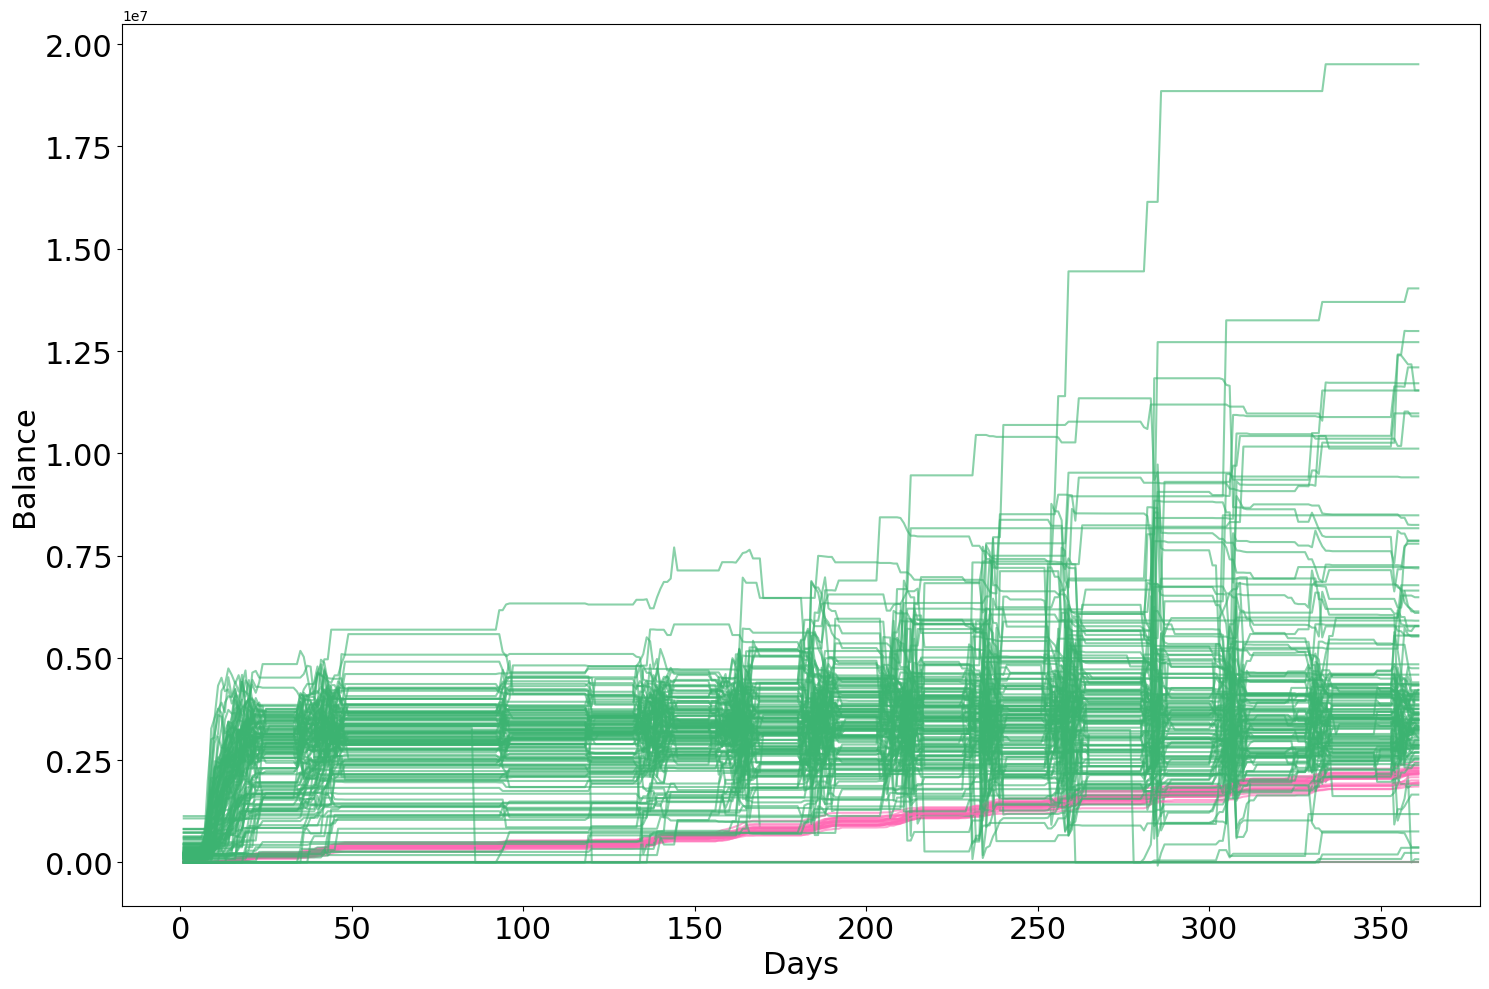

In [20]:
import matplotlib.pyplot as plt

# Plot the balance evolution for all users (columns) as separate lines
# plt.figure(figsize=(15,10), dpi= 300)
plt.figure(figsize=(15,10))

# Plot each column (account balance) as a line
for user in balance_df.columns:
    color = 'mediumseagreen' if user.startswith('C') else 'hotpink'

    plt.plot(balance_df.index, balance_df[user], color=color, label=f"User {user}", alpha=0.6)

# Add title and labels
plt.xlabel("Days", fontsize=22)
plt.ylabel("Balance", fontsize=22)

# Rotate x-axis labels for better visibility
plt.tick_params(axis='x', labelsize=22)
plt.tick_params(axis='y', labelsize=22)

# Display the plot
plt.tight_layout()
plt.show()

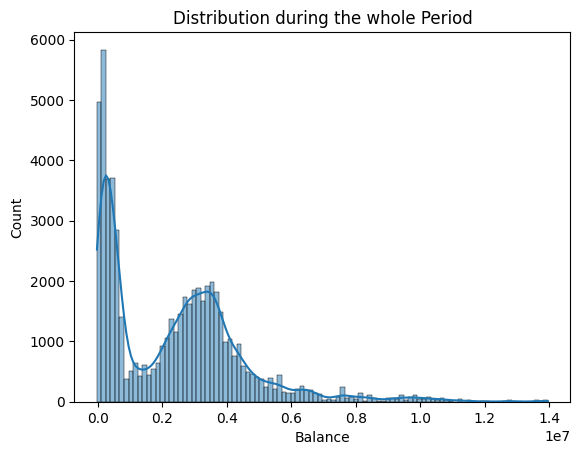

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
values_df = balance_df.values.flatten()
# Plot distribution for all the days (aggregated over users and days)
sns.histplot(values_df, bins=100, kde=True)
plt.title("Distribution during the whole Period")
plt.xlabel("Balance")
plt.show()

In [9]:
balance_df.T

,0,1,2,3,4,5,6,7,8,9,...,355,356,357,358,359,360,361,362,363,364
C4335240963,55.90,55.90,55.90,55.90,55.90,55.90,55.90,55.90,55.90,55.90,...,5654722.61,5654722.61,5649389.58,5649389.58,5649389.58,5649389.58,5649389.58,5649389.58,5649389.58,5649389.58
C9522727029,126.25,146.25,146.25,166.25,196.25,196.25,216.25,236.25,236.25,256.25,...,4325688.14,4308639.42,4308849.42,4308899.42,4308949.42,4308999.42,4308999.42,4308999.42,4308999.42,4309019.42
C7602185929,-37.09,-37.09,-37.09,-37.09,-37.09,-37.09,-37.09,-37.09,-37.09,327371.26,...,8656469.94,9218819.32,9218819.32,9218819.32,9218819.32,9218819.32,9218819.32,9218819.32,9218819.32,9218819.32
C1262480323,21.26,242101.31,242101.31,242081.31,242081.31,242081.31,242081.31,242081.31,242081.31,305525.27,...,6515200.95,5301859.76,5301859.76,5629018.38,5629018.38,5738186.74,5738186.74,5738186.74,5738186.74,5738186.74
C6506305345,134295.41,134295.41,134295.41,134295.41,134295.41,134295.41,134295.41,280727.89,280727.89,501142.53,...,1887497.40,1887497.40,1887497.40,1852957.82,1852957.82,1849809.35,1849809.35,1849809.35,1849809.35,1849809.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C8381977371,341753.40,341753.40,341753.40,341753.40,341753.40,341753.40,341753.40,341753.40,341753.40,341753.40,...,6400822.83,6400822.83,6400822.83,6400822.83,6400822.83,6400822.83,6400822.83,6400822.83,6400822.83,6400822.83
C7358006423,150666.16,150666.16,150666.16,150666.16,150666.16,150666.16,150666.16,150666.16,150666.16,150666.16,...,2856366.76,2836242.48,2736494.51,2736494.51,2835337.07,2824443.98,2824443.98,2824443.98,2824443.98,2824443.98
C4938085849,149812.68,149812.68,149812.68,149812.68,149812.68,149812.68,149812.68,149812.68,149812.68,149812.68,...,1278948.89,1278948.89,1278948.89,1278948.89,1278948.89,1278948.89,1278948.89,1278948.89,1278948.89,1278948.89
C0998959265,144144.55,144144.55,144144.55,144144.55,144144.55,144144.55,144144.55,144144.55,144144.55,144144.55,...,1564628.37,1564628.37,1564628.37,1564628.37,1564578.37,1564578.37,1564578.37,1564578.37,1564578.37,1564578.37


# SQUIC

In [10]:
df = balance_df

In [11]:
ROWS = len(df.iloc[0])
ROWS

163

In [12]:
import numpy as np

In [13]:
Y = df.T.to_numpy()
# normalize the Y input data to achieve unit variance
Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation
# normalizes each row so that the std dev of each user's balance over the days becomes 1

# Y_new has shape (Users × Days).
# S will have shape (Users × Users).

# double check if this is correct by 
S = np.cov(Y_new, bias=True) # "bias=true" you force cove to use n samples instead of n-1

/var/folders/s6/4jprwbqj4012tkll2ww6r5hr0000gq/T/ipykernel_6175/3409128255.py:3: RuntimeWarning: divide by zero encountered in divide
  Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation


In [14]:
l = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5]

In [15]:
from SQUIC_functions import *

In [16]:
rho_dict = {}

data_nnz = []
data_nnzr = []
data_time = []

for rho in l:
    X, computation_time = compute_squic(Y_new, rho)
    computation_time = round(computation_time, 2)
    rho_dict[rho] = X
    print(f"time required: {computation_time} seconds")

    nonz, nonz_r = count_nnz(rho_dict[rho], ROWS)

    data_nnz.append(nonz)
    data_nnzr.append(nonz_r)
    data_time.append(computation_time)

    if nonz == ROWS:
        print(f"For rho = {rho} just element on the diagonal")
        # sparsity_pattern(rho_dict[rho])
    elif nonz == ROWS * ROWS:
        print(f"For rho = {rho} big dense matrix")
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
        # sparsity_pattern(rho_dict[rho])
    else:
        print(f"For rho = {rho} there are some nnz")
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
        # sparsity_pattern(rho_dict[rho])


data_df = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time
]

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           163 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.16e-03 nnz(S)/p=1.36e+02
# Cholesky Failed: Exiting at current iterate.#SQUIC Finished: time=3.76e-02 nnz(X,W)/p=[1.36e+02 1.00e+00] 

time required: 0.04 seconds
For rho = 0.1 there are some nnz
nnz = 161
nnz/row = 0.9877300613496932
----------------------------------------------------------------
        

# SQUIC-Fit

In [17]:
fit_dict = {}

In [18]:
Y = df.T.to_numpy()  # Convert to (users, days)

# normalize the Y input data to achieve unit variance
Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation
# normalizes each row so that the std dev of each user's balance over the days becomes 1

# Y_new has shape (Users × Days).
# S will have shape (Users × Users).

# double check if this is correct by 
S = np.cov(Y_new, bias=True) # "bias=true" you force cove to use n samples instead of n-1

/var/folders/s6/4jprwbqj4012tkll2ww6r5hr0000gq/T/ipykernel_6175/1629358900.py:4: RuntimeWarning: divide by zero encountered in divide
  Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation


In [19]:
data_nnz = []
data_nnzr = []
data_time = []

for rho in l:
    start = time.time()
    fit_dict[rho] = squic_fit(Y_new, lambda_val=rho, eta=rho * 0.1)
    end = round(time.time() - start, 2)
    print(f"required time: {end}")
    nnz, nnz_r = nnz_fit(fit_dict[rho], 100)
    print(f"nnz = {nnz} per rows = {nnz_r}")

    sparsity_pattern(fit_dict[rho])

    data_nnz.append(nnz)
    data_nnzr.append(nnz_r)
    data_time.append(end)

data_fit = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time
]

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           163 x 365 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=8.93e-04 nnz(S)/p=1.36e+02
# Cholesky Failed: Exiting at current iterate.#SQUIC Finished: time=2.14e-02 nnz(X,W)/p=[1.36e+02 1.00e+00] 



AttributeError: 'list' object has no attribute 'todense'

In [ ]:
import tabulate

def table(data, title, l):
    table = tabulate(
        data,
        headers=[title] + l,
        tablefmt="fancy_grid",
        numalign="center",
        stralign="center"
    )
    return table

In [ ]:
print(table(data_df, "SQUIC NORM", l))

print(table(data_fit_norm, "SQUIC FIT NORM", l))